## Homework 8 - due Friday, April 12 by 4 PM 

Name: Kristen Townsend

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

### Problem 1:

In [2]:
# define functions for the differential equations
def f(r,t):
    y = r[0]
    v = r[1]

    fy = v
    fv = -y - 10*y**3
    
    return np.array([fy,fv], float)

# apply 4th order runge-kutta
def height(v,tpts,h):
    # tpts = array of time values spaced by h
    # v = initial velocity
    r = np.array([1.0, v], float) # y(0) = 1, y'(0) = v
    for t in tpts:
        k1 = h*f(r,t)
        k2 = h*f(r+0.5*k1, t+0.5*h)
        k3 = h*f(r+0.5*k2, t+0.5*h)
        k4 = h*f(r+k3, t+h)
        r += (k1 + 2*k2 + 2*k3 + k4) / 6
    return r[0]

# define range of values
t1 = 0.0
t2 = 1.0
y1 = 1.0
y2 = 2.0

N = 1000
h = (t2-t1)/N
tpts = np.arange(t1,t2+h,h)

# target accuracy
target = 1e-8

# finding where the sign switch occurs
#for v in np.linspace(0, 50, 15):
#    print("\nv:",v, "\nvalue:", height(v,tpts,h) - y2)

# initial guesses
v1 = 10.0
v2 = 15.0

# apply binary search to find the root
h1 = height(v1,tpts,h) - y2
h2 = height(v2,tpts,h) - y2
#print(h1,h2)

# binary search method
while abs(h2-h1) > target:
    vp = (v1+v2)/2
    hp = height(vp,tpts, h) - y2
    if h1*hp > 0:
        v1 = vp
        h1 = hp
    else:
        v2 = vp
        h2 = hp

v = (v1+v2)/2
print("Solution:", round(v,2))

Solution: 14.09


##### Explanation: 

Find a solution of the boundary value problem:
$$\frac{d^2y}{dt^2} = -y-10y^3$$
where $y(t=0)=1$ and $y(t=1)=2$ with $0<\frac{dy}{dx}<50.$ \
Be careful with your starting point for the binary search method.

Differential equations used:
$$ \frac{dy}{dt} = v \qquad \frac{dv}{dt} = -y-10y^3 $$


I first started by defining functions for the fourth-order runge-kutta numerical method and the differential equations determined from the second-order differential equation given in the problem. I then initialized the bounds of the problem, a step size for the runge-kutta method, and an array of time steps for each point in the equation.

Because I was having some initial difficulties with the bounds of my search area, I applied fourth-order runge-kutta to find calculate the values of the differential equations at a specific time step to find where the values switch between positive and negative, indicating the location of a solution. 

Once I determined the rough area of the solution, I limited my initial guesses and applied the binary search method to find the solution to the problem!

### Problem 2:

In [3]:
# potential energy
def U(x):
    return x**2

# differential equation functions
def oscillator(r,x,E):
    y = r[0]
    p = r[1]

    fy = p
    fp = -E*y + U(x)*y

    return np.array([fy,fp], float)

# applies RK4 to calculate wavefunction for particular energy
def wavefn_RK4(E):
    r = np.array([0.0,1.0], float) # initial guesses for y, v

    # dependant of x, not t
    xpts = np.arange(x1, x2+h, h)

    for x in xpts:
        k1 = h*oscillator(r,x,E)
        k2 = h*oscillator(r+0.5*k1, x+0.5*h,E)
        k3 = h*oscillator(r+0.5*k2, x+0.5*h,E)
        k4 = h*oscillator(r+k3, x+h,E)
        r += (k1 + 2*k2 + 2*k3 + k4) / 6
    
    return r[0]

# applies binary search method
def binary(E1, E2):
    
    h1 = wavefn_RK4(E1)
    h2 = wavefn_RK4(E2)

    target = 1e-8

    while abs(E2-E1) > target:
        Ep = (E1+E2)/2
        hp = wavefn_RK4(Ep)
        if h1*hp > 0:
            E1 = Ep
            h1 = hp
        else:
            E2 = Ep
            h2 = hp
    
    return (E1+E2)/2


# constants
x1 = -5.0
x2 = 5.0
y1 = 0.0
y2 = 0.0

N = 2000
h = (x2-x1)/N

# guessing range, limiting this to include only the first 4 eigenvalues
E1 = 0.0
E2 = 8.0

# find ranges for eigenvalue locations using the guessing range
E_vals = np.linspace(E1, E2, 20)
osc_vals = [wavefn_RK4(E) for E in E_vals]

ranges = []

for i in range(len(E_vals)-1):
    # looking to see if there is a sign change between osc_vals[i] and osc_vals[i+1]
    if osc_vals[i]*osc_vals[i+1] < 0: 
        ranges.append((E_vals[i], E_vals[i+1]))


# determine energy using the binary search method
eigenvals = []

for (E1, E2) in ranges:
    eigenvals.append(binary(E1,E2))

# print results
print("The first 4 eigenvalues are:")
for i in range(len(eigenvals)):
    print("  ", round(eigenvals[i],2))


The first 4 eigenvalues are:
   1.0
   3.0
   5.0
   7.0


#### Explanation: 

Find the first 4 eigenvalues of the confined harmonic oscillator with 
$$\frac{d^2y}{dx^2} = -Ey + U(x)y$$
$$U(x) = x^2 \text{ for} -5<x<5$$
where $y(x=-5)=0$ and $y(x=5)=0$

Differential equations used:
$$\frac{dy}{dx} = p \qquad \frac{dp}{dx} = -Ey + U(x)y $$


I first initialized functions for the problem's potential energy, the differential functions involved, and a function that applies the fourth-order runge-kutta method to calculate the value of the differential wave functions for a given energy. I also created a function that applies the binary search method, though it isn't called enough to really constitute a special function. Oh well.

I then list the initial conditions given within the problem and determine a step size for the runge-kutta method. To find the rough values of each eigenvalue, I then iterated through an initial guessing range to find where the wavefunction would switch between a positive or negative sign. Once a switch was found, the energy values surrounding it were recorded as pairs into a list to later be used with the binary search method to determine the exact value. The guessing range was initially limited to find only the first 4 eigenvalues. 

I then used the binary search method to determine the exact eigenvalues to a certain target value, and printed the results! I found the first 4 eigenvalues to be 1.0, 3.0, 5.0, and 7.0. Because the wavefunction seems to be periodic, I think this pattern will continue and the 5th eigenvalue with be 9.0, the 6th will be 11.0, and so on.

### Problem 3: Exercise 10.1, page 454

In [4]:
# part a
# roll the dice
dice1 = random.randrange(6) + 1
dice2 = random.randrange(6) + 1

# print results
print("Dice 1 rolled a", dice1)
print("Dice 2 rolled a", dice2)

Dice 1 rolled a 2
Dice 2 rolled a 6


In [5]:
# part b
# counters
N = 1000000
sixes = 0

# loop through
for i in range(N):
    dice1 = random.randrange(6) + 1
    dice2 = random.randrange(6) + 1

    # conditional statement
    if dice1 == dice2 == 6:
        sixes += 1

# calculate fraction of times a six appears
fracof6 = sixes / N

print("Calculated fraction:    ",fracof6)
print("Initial estimate (1/36):", 1/36)

Calculated fraction:     0.027687
Initial estimate (1/36): 0.027777777777777776


#### Explanation: 

For part (a) I imported the random library to use the function .randrange(n). Using this function returns a random number between zero and n-1. Because this situation is modeling a physical dice that goes from 1 to 6, I simply increased the value by 1. 

To keep track of the number of times a double six was rolled for part (b), I created a for loop that steadily increases a counter once a condition is met. After both dice are 'rolled', an if statement checks if they were both sixes or not. If yes, the counter increases by one. Once the loop has been iterated through N times, I calculate the fraction of double sixes rolled out of the total rolls (N=1,000,000). 

Comparing the calculated fraction against the expected value (1/36), there is a close agreement between the two. The accuracy of the calculated value will increase as the number of total data points increases.

### Problem 4: Exercise 10.2, page 460

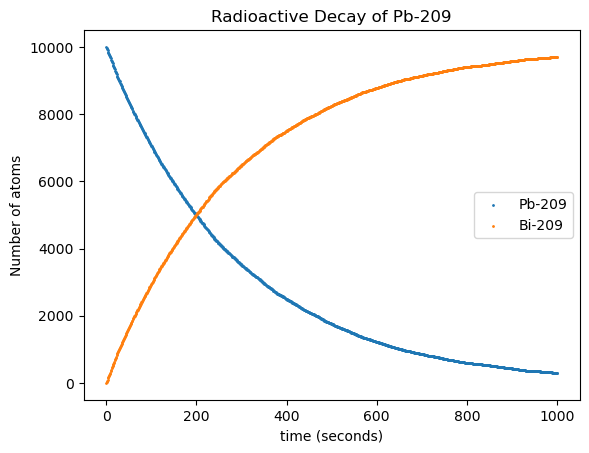

In [6]:
# part a
# determine constants
N_Pb = 10000
N_Bi209 = 0
tau = 3.3*60 # half-life of Pb in seconds

# time
h = 1 # time-step
tmax = 1000

# probability of decay
p = 1-2**(-h/tau)

# create arrays to loop through
tpts = np.arange(0.0, tmax+h, h)
Pb_pts = []
Bi209_pts = []

# loop through points
for i in tpts:
    Pb_pts.append(N_Pb)
    Bi209_pts.append(N_Bi209)

    # determine how many points decay
    decay = 0
    for i in range(N_Pb):
        if random.random() < p:
            decay += 1
    # change the number of atoms
    N_Pb -= decay
    N_Bi209 += decay 


# graph overall results
plt.scatter(tpts, Pb_pts, s=1, label="Pb-209")
plt.scatter(tpts, Bi209_pts, s=1, label="Bi-209")
plt.legend()
plt.xlabel('time (seconds)')
plt.ylabel('Number of atoms')
plt.title('Radioactive Decay of Pb-209')
plt.show()

Part (a) focuses on modeling the decay from Pb-209 to Bi-209. The decay is modeled by determining if a random number chosen by the .random() function is within the probability of decay for Pb $(p = 1 - 2^{-h/\tau})$. Each atom is checked for each time point, and the number of atoms of each element are updated accordingly.

This creates a shallow exponential decay/increase of atoms from a half-life of 3.3 minutes.

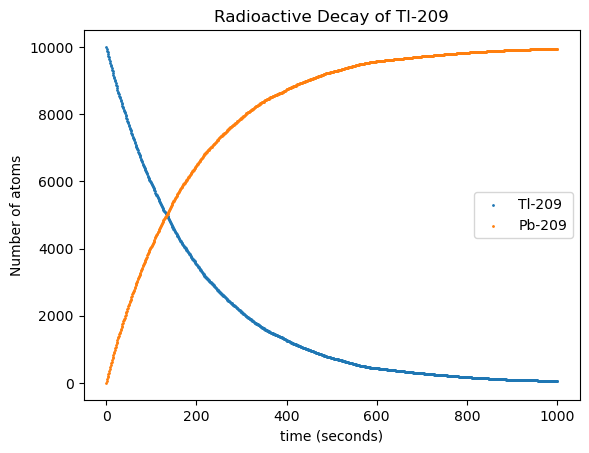

In [7]:
# part b

# determine constants
N_Tl = 10000
N_Pb = 0
tau = 2.2*60 # half-life of Tl-209 in seconds

# time
h = 1 # time-step
tmax = 1000

# probability of decay
p = 1-2**(-h/tau)

# create arrays to loop through
tpts = np.arange(0.0, tmax+h, h)
Tl_pts = []
Pb_pts = []

# loop through points
for i in tpts:
    Tl_pts.append(N_Tl)
    Pb_pts.append(N_Pb)

    # determine how many points decay
    decay = 0
    for i in range(N_Tl):
        if random.random() < p:
            decay += 1
    # change the number of atoms
    N_Tl -= decay
    N_Pb += decay 


# graph overall results
plt.scatter(tpts, Tl_pts, s=1, label="Tl-209")
plt.scatter(tpts, Pb_pts, s=1, label="Pb-209")
plt.legend()
plt.xlabel('time (seconds)')
plt.ylabel('Number of atoms')
plt.title('Radioactive Decay of Tl-209')
plt.show()

Part (b) focuses on modeling the decay from Tl-209 to Pb-209. This model functions the same way as part (a), but results in a slightly steeper exponential decay/increase of atoms from a half-life of 2.2 minutes.

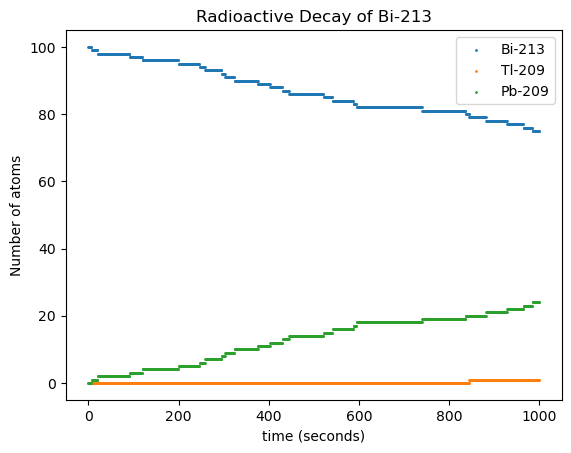

In [10]:
# part c

# determine constants
N_Bi213 = 100
N_Tl = 0
N_Pb = 0
tau_Bi213 = 46.0*60 # half-life of Bi-213 in seconds
tau_Tl = 2.2*60 # half-life of Tl in seconds

# time
h = 1 # time-step
tmax = 1000

# probability of decay
p_Bi213 = 1-2**(-h/tau_Bi213)
p_Tl = 1-2**(-h/tau_Tl)

# create arrays to loop through
tpts = np.arange(0.0, tmax+h, h)
Bi213_pts = []
Tl_pts = []
Pb_pts = []

# loop through points
for t in tpts:
    Bi213_pts.append(N_Bi213)
    Tl_pts.append(N_Tl)
    Pb_pts.append(N_Pb)

    # Bi decay
    decay_Bi = 0
    to_Tl = 0
    to_Pb = 0

    for j in range(N_Bi213):
        if random.random() < p_Bi213: # will it decay?
            decay_Bi += 1

            # conditionals for Tl
            if random.random() < 0.9791: #which way?
                to_Pb += 1
            else:
                to_Tl += 1

    # Tl decay
    decay_Tl = 0
    for k in range(N_Tl):
        if random.random() < p_Tl:
            decay_Tl += 1

    # update all populations
    N_Bi213 -= decay_Bi
    N_Tl += to_Tl - decay_Tl
    N_Pb += to_Pb + decay_Tl


# graph overall results
plt.scatter(tpts, Bi213_pts, s=1, label="Bi-213")
plt.scatter(tpts, Tl_pts, s=1, label="Tl-209")
plt.scatter(tpts, Pb_pts, s=1, label="Pb-209")
plt.legend()
plt.xlabel('time (seconds)')
plt.ylabel('Number of atoms')
plt.title('Radioactive Decay of Bi-213')
plt.show()

Part (c) focuses on modeling the decay from Bi-213 to Tl-209 *or* Pb-209. 

After determining if an atom will decay at all, as happens in part (a) and (b), there is another conditional to determine if the atom will decay into Pb-209 or Tl-209. If it decays into Pb, as most will, then this part is done. If it decays into Tl, there is now another probability conditional to see if it will decay *again* into Pb. With its relatively short half-life, Tl decays much quicker and appears to be a straight line at zero. You can see it change a little if your time step is small enough to see the individual points!

Any 'probability' is determined by conditionally checking if a randomly generated number is within the decimal percentage probability of an event occuring. 

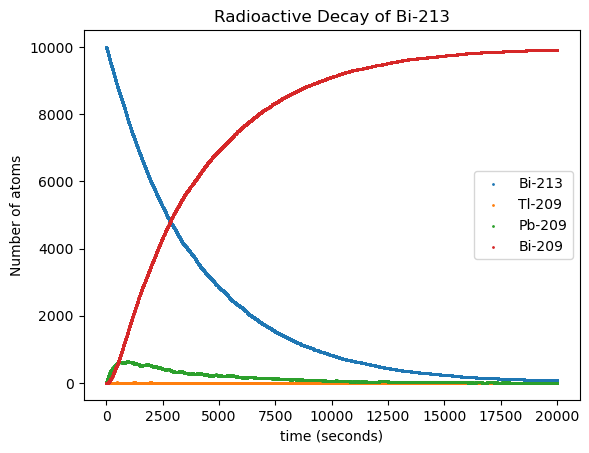

In [13]:
# all together now!
# determine constants

# initialize populations
N_Bi213 = 10000
N_Tl = 0
N_Pb = 0
N_Bi209 = 0

# half-lives
tau_Bi213 = 46.0*60 # half-life of Bi213 in seconds
tau_Tl = 2.2*60 # half-life of Tl in seconds
tau_Pb = 3.3*60 # half-life of Pb in seconds

# time
h = 1 # time-step
tmax = 20000

# probabilities of decay
p_Bi213 = 1-2**(-h/tau_Bi213)
p_Tl = 1-2**(-h/tau_Tl)
p_Pb = 1-2**(-h/tau_Pb)

# create storage arrays to loop through
tpts = np.arange(0.0, tmax+h, h)
Bi213_pts = []
Tl_pts = []
Pb_pts = []
Bi209_pts = []

# MAIN LOOP HERE
for t in tpts:
    # current populations
    Bi213_pts.append(N_Bi213)
    Tl_pts.append(N_Tl)
    Pb_pts.append(N_Pb)
    Bi209_pts.append(N_Bi209)

    # decays based on current populations
    # Bi 213 decay
    decay_Bi = np.random.binomial(N_Bi213, p_Bi213)
    to_Tl = np.random.binomial(decay_Bi, 0.0209)
    to_Pb = decay_Bi - to_Tl

    # Tl decays?
    decay_Tl = np.random.binomial(N_Tl, p_Tl)

    # Pb decays?
    decay_Pb = np.random.binomial(N_Pb, p_Pb)

    # update all
    N_Bi213 -= decay_Bi
    N_Tl += to_Tl - decay_Tl
    N_Pb += to_Pb + decay_Tl - decay_Pb
    N_Bi209 += decay_Pb


# graph overall results
plt.scatter(tpts, Bi213_pts, s=1, label="Bi-213")
plt.scatter(tpts, Tl_pts, s=1, label="Tl-209")
plt.scatter(tpts, Pb_pts, s=1, label="Pb-209")
plt.scatter(tpts, Bi209_pts, s=1, label="Bi-209")

plt.legend()
plt.xlabel('time (seconds)')
plt.ylabel('Number of atoms')
plt.title('Radioactive Decay of Bi-213')
plt.show()

#### Explanation: 

To make an overall plot, for every time step I begin by recording the current population of each atom. Decays are then based on these current populations. I found that the np.random.binomial() function models a binomial distribution (bell curve), which I was able to use to determine if an atom decays or not. I use this function for each 'step' of the decay and then update all the different populations at the end of the loop.

As the plot shows, this decay results in practically all atoms becoming the 'stable' Bi-209 after enough time has elapsed. There is more Pb in the very beginning, but it quickly begins to decay further into Bi-209, and that value quickly becomes dominant.

The book makes a note that you should work through the decay chain from the bottom up, but I don't think this is the best way to go about this problem. Because each step is reliant on the number of atoms left from the previous state, working through backwards takes up more time and needs to be completely switched at the end regardless. 

### Problem 5: Exercise 10.4, page 463

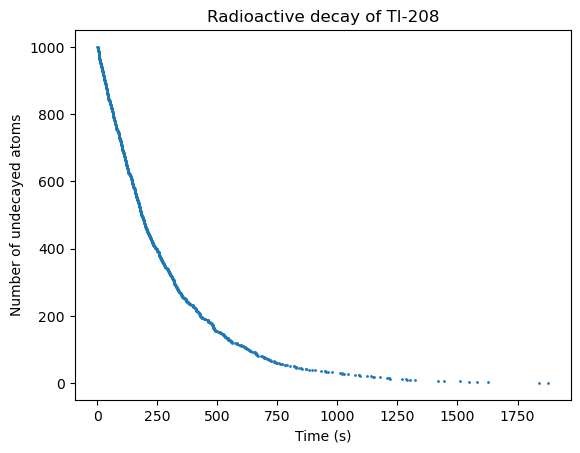

In [14]:
# define the function for probability distribution
def nonuniform(tau):
    z = random.random()
    return -(1/(np.log(2)/tau))*np.log(1-z)

# constants
tau = 3.053*60 # half-life in seconds of Tl-208
N = 1000 # number of atoms

# array of atom decay times
atom_decay = np.zeros(N)

# fill the array
for i in range(N):
    atom_decay[i] = nonuniform(tau)
    
# sort decay times
sorted_decay = np.sort(np.array(atom_decay))

# number of atoms remaining at each time
N_remaining = N - np.arange(N)

# plot the number of atoms decaying
plt.scatter(sorted_decay, N_remaining, s=1)
plt.xlabel("Time (s)")
plt.ylabel("Number of undecayed atoms")
plt.title("Radioactive decay of Tl-208")
plt.show()

#### Explanation: 

I first filled an array of decay times which fit with the nonuniform distribution of random numbers following $x = - \frac{1}{\mu}\ln{1-z}$ where $\mu = \ln{2}/\tau$. I then sort these times from smallest to largest using the np.sort() function. This array is used for my x-axis.

To have an array which decreases by one for each index as atoms gradually decay, I just subtracted an array built using np.arange(N) from the original number of atoms N. This array is used for my y-axis.

This works because the first decay happens at the earliest time, the second is second earliest, etc. The time scale along the x-axis is not a uniform spacing.